# Tutorial 07- Convolutional Neural Networks

# Download the Dataset
We are using cats vs. dogs dataset used in previous Tutorials. Dataset can be downloaded from https://www.microsoft.com/en-us/download/details.aspx?id=54765

**Data**: Labeled images of dogs and cats.  
We want to learn a **classifier**: A function that returns a label (here: `cat`/`dog`) for images

In [1]:
from tqdm.notebook import tqdm
import numpy as np
import torch
import torch.nn as nn
import PIL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("We are using {}".format(device))

We are using cuda


In [2]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Resize, ToTensor, Normalize, Compose
root_dir = '../PetImages'

target_size = (32, 32)
transforms = Compose([Resize(target_size), # Resizes image
                    ToTensor(),           # Converts to Tensor, scales to [0, 1] float (from [0, 255] int)
                    Normalize(mean=(0.5, 0.5, 0.5,), std=(0.5, 0.5, 0.5)), # scales to [-1.0, 1.0]
                    ])
corrupted_files = ["../PetImages/Cat/666.jpg", "../PetImages/Dog/11702.jpg"]
dataset_ = ImageFolder(
    root_dir, 
    transform=Resize((40,40)), 
    is_valid_file=lambda x: x.endswith("jpg") and x not in corrupted_files)

In [3]:
class RAMDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        data = []
        for sample in tqdm(dataset):
            data.append(sample)
        self.n = len(data)
        self.data = data
        self.transform = transform
        
    def __getitem__(self, ind):
        if self.transform is not None:
            return self.transform(self.data[ind][0]), self.data[ind][1]
        else:
            return self.data[ind]
    
    def set_tranform(self, transform):
        self.transform = transform
    
    def __len__(self):
        return self.n

In [4]:
dataset = RAMDatasetWrapper(dataset_, transform=transforms)

  0%|          | 0/24998 [00:00<?, ?it/s]

/home/rodrigo/myenv/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [5]:
train_set, val_set = torch.utils.data.random_split(dataset, [22000, 2998])

In [6]:
from torch.utils.data import DataLoader
batch_size = 64

train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)

# Baseline - MLP model
### We will compare MLP and ConvNets in terms of accuracy, number of parameters, etc.

In [7]:
from utils_train import fit, plot

In [8]:
class MLPModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

In [9]:
model_mlp = MLPModel(32*32*3, 128)
model_mlp = model_mlp.to(device)
learning_rate = 0.001
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=learning_rate)
n_epochs = 25
loss_fn = nn.CrossEntropyLoss()

In [10]:
curves_mlp = fit(train_dataloader, val_dataloader, model_mlp, optimizer, loss_fn, n_epochs)

Epoch 1/25: train_loss: 0.6518, train_accuracy: 61.4682, val_loss: 0.6247, val_accuracy: 63.5757
Epoch 2/25: train_loss: 0.6187, train_accuracy: 65.1773, val_loss: 0.6182, val_accuracy: 65.0767
Epoch 3/25: train_loss: 0.6004, train_accuracy: 67.0455, val_loss: 0.6137, val_accuracy: 65.5103
Epoch 4/25: train_loss: 0.5827, train_accuracy: 68.4273, val_loss: 0.6060, val_accuracy: 67.5117
Epoch 5/25: train_loss: 0.5611, train_accuracy: 70.1682, val_loss: 0.6210, val_accuracy: 66.7779
Epoch 6/25: train_loss: 0.5418, train_accuracy: 71.5591, val_loss: 0.6221, val_accuracy: 65.7105
Epoch 7/25: train_loss: 0.5188, train_accuracy: 72.9864, val_loss: 0.6121, val_accuracy: 66.2108
Epoch 8/25: train_loss: 0.4962, train_accuracy: 74.8364, val_loss: 0.6402, val_accuracy: 66.4109
Epoch 9/25: train_loss: 0.4719, train_accuracy: 76.3182, val_loss: 0.6667, val_accuracy: 66.5110
Epoch 10/25: train_loss: 0.4470, train_accuracy: 77.7091, val_loss: 0.6848, val_accuracy: 66.8112
Epoch 11/25: train_loss: 0.42

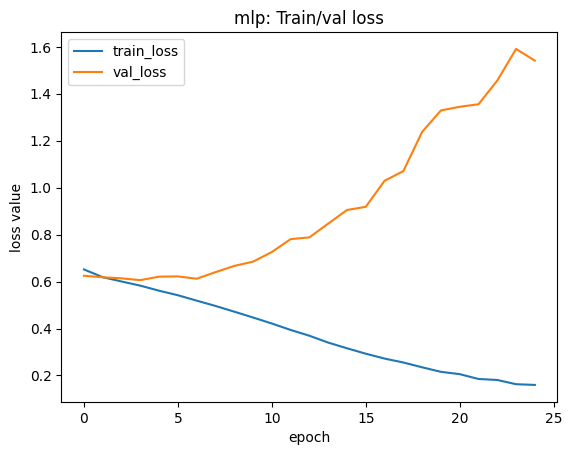

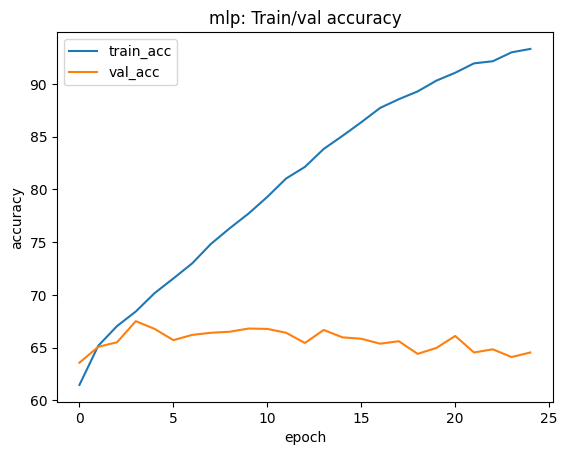

In [16]:
plot(curves_mlp[0], curves_mlp[2], curves_mlp[1], curves_mlp[3], title='mlp')

### With some regularization the best accuracy we got before for this MLP model was ~71%

## Convolutional Neural Network
### Two convolutions with Max Pooling, followed by linear layer on flattened feature maps

In [11]:
class ConvModel(nn.Module):
    
    def __init__(self):
        super(ConvModel, self).__init__()
        self.conv_layers = nn.Sequential(
            # input size: 3x32x32
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            # output: 16x28x28 (because kernel_size=5 and no padding)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: 16x14x14
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            # output: 32x10x10
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: 32x5x5
        )
        self.linear_layer = nn.Linear(32*5*5, 2) # map output of conv layers to number of outputs (2 classes in this case)
    
    def forward(self, input):
        output = self.conv_layers(input) # NO FLATTENING HERE, expected input is of dimension batch_size x n_channels x im_height x im_width
        output = output.view(output.size(0), 32*5*5) # Flatten to a vector before passing to a linear layer
        output = self.linear_layer(output)
        return output

In [12]:
model_conv = ConvModel()
model_conv = model_conv.to(device)
learning_rate = 0.001
optimizer = torch.optim.Adam(model_conv.parameters(), lr=learning_rate)
n_epochs = 25
loss_fn = nn.CrossEntropyLoss()

In [13]:
curves_conv1 = fit(train_dataloader, val_dataloader, model_conv, optimizer, loss_fn, n_epochs)

Epoch 1/25: train_loss: 0.6271, train_accuracy: 64.4818, val_loss: 0.5845, val_accuracy: 69.0460
Epoch 2/25: train_loss: 0.5561, train_accuracy: 71.4636, val_loss: 0.5540, val_accuracy: 71.5811
Epoch 3/25: train_loss: 0.5176, train_accuracy: 74.6273, val_loss: 0.5041, val_accuracy: 75.9840
Epoch 4/25: train_loss: 0.4873, train_accuracy: 76.6000, val_loss: 0.5006, val_accuracy: 75.7839
Epoch 5/25: train_loss: 0.4681, train_accuracy: 77.7000, val_loss: 0.4892, val_accuracy: 76.4843
Epoch 6/25: train_loss: 0.4513, train_accuracy: 78.7227, val_loss: 0.4867, val_accuracy: 77.5183
Epoch 7/25: train_loss: 0.4333, train_accuracy: 79.7773, val_loss: 0.4809, val_accuracy: 77.3182
Epoch 8/25: train_loss: 0.4163, train_accuracy: 80.8636, val_loss: 0.4731, val_accuracy: 78.0854
Epoch 9/25: train_loss: 0.4029, train_accuracy: 81.4091, val_loss: 0.4630, val_accuracy: 77.7518
Epoch 10/25: train_loss: 0.3903, train_accuracy: 82.0500, val_loss: 0.4686, val_accuracy: 78.2855
Epoch 11/25: train_loss: 0.37

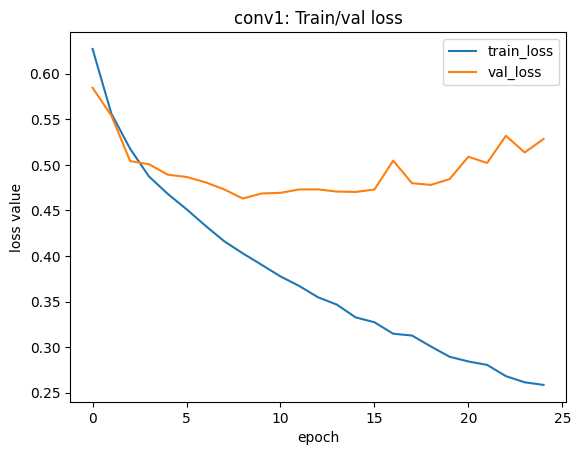

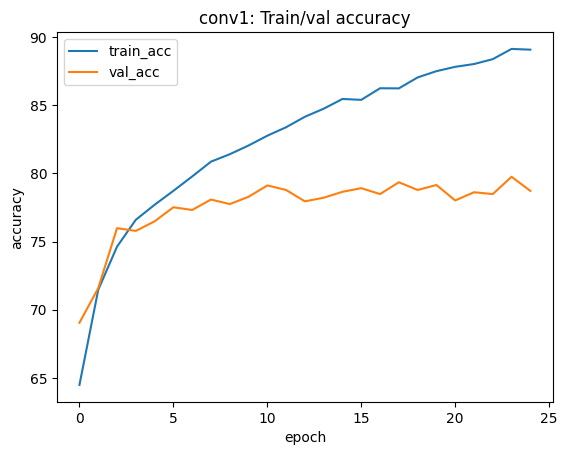

In [14]:
plot(curves_conv1[0], curves_conv1[2], curves_conv1[1], curves_conv1[3], title='conv1')

In [ ]:
class ConvModel2(nn.Module):
    
    def __init__(self):
        super(ConvModel2, self).__init__()
        self.conv_layers = nn.Sequential(
            # input size: 3x32x32
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            # output: 16x28x28 (because kernel_size=5 and no padding)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: 16x14x14
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            # output: 32x10x10
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: 32x5x5
            nn.AvgPool2d(kernel_size=5, stride=5) # alternatively: AdaptiveAvgPool(1)
            # output: 32x1x1
        )
        self.linear_layer = nn.Linear(32, 2)
    
    def forward(self, input):
        output = self.conv_layers(input)
        output = output.view(output.size(0), 32)
        output = self.linear_layer(output)
        return output

In [18]:
model_conv2 = ConvModel2()
model_conv2 = model_conv2.to(device)
learning_rate = 0.001
optimizer = torch.optim.Adam(model_conv2.parameters(), lr=learning_rate)
n_epochs = 25
loss_fn = nn.CrossEntropyLoss()

In [19]:
curves_conv2 = fit(train_dataloader, val_dataloader, model_conv2, optimizer, loss_fn, n_epochs)

Epoch 1/25: train_loss: 0.6617, train_accuracy: 59.3273, val_loss: 0.6464, val_accuracy: 62.7752
Epoch 2/25: train_loss: 0.6210, train_accuracy: 65.5318, val_loss: 0.5952, val_accuracy: 68.4456
Epoch 3/25: train_loss: 0.5911, train_accuracy: 68.8455, val_loss: 0.5709, val_accuracy: 70.5804
Epoch 4/25: train_loss: 0.5703, train_accuracy: 70.8727, val_loss: 0.5685, val_accuracy: 71.1474
Epoch 5/25: train_loss: 0.5552, train_accuracy: 71.8773, val_loss: 0.5447, val_accuracy: 72.4483
Epoch 6/25: train_loss: 0.5441, train_accuracy: 72.8500, val_loss: 0.5330, val_accuracy: 74.2829
Epoch 7/25: train_loss: 0.5386, train_accuracy: 73.0409, val_loss: 0.5278, val_accuracy: 74.0827
Epoch 8/25: train_loss: 0.5251, train_accuracy: 74.3000, val_loss: 0.5279, val_accuracy: 73.4823
Epoch 9/25: train_loss: 0.5183, train_accuracy: 74.4591, val_loss: 0.5119, val_accuracy: 75.6838
Epoch 10/25: train_loss: 0.5178, train_accuracy: 74.7273, val_loss: 0.5241, val_accuracy: 74.2495
Epoch 11/25: train_loss: 0.50

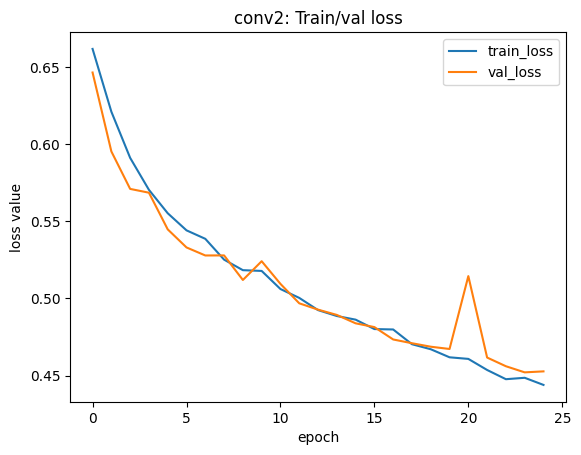

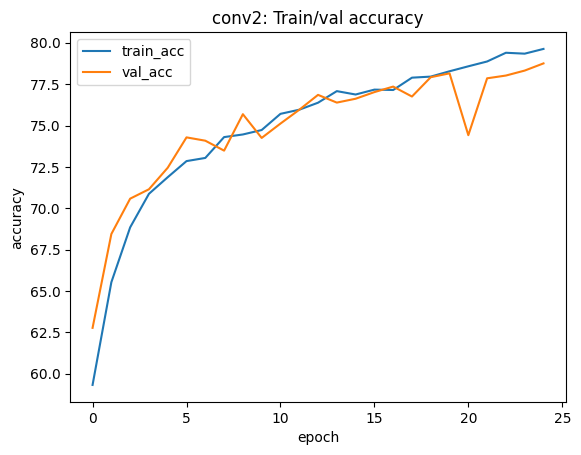

In [20]:
plot(curves_conv2[0], curves_conv2[2], curves_conv2[1], curves_conv2[3], title='conv2')

# Compare number of parameters

In [21]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [22]:
print('MLP: {} parameters'.format(count_parameters(model_mlp)))
print('ConvNet1: {} parameters'.format(count_parameters(model_conv)))
print('ConvNet2: {} parameters'.format(count_parameters(model_conv2)))

MLP: 426626 parameters
ConvNet1: 15650 parameters
ConvNet2: 14114 parameters


__Model MLP__:
- 1st layer: (32 * 32 * 3)*128 + 128 (biases) __// input size dependant, 92% of parameters!__
- 2nd layer: 128 * 128 + 128
- 3rd layer: 128 * 128 + 128
- 4th layer: 128 * 2 + 2

__Model ConvNet1__:
- 1st layer (conv): 16 * 3 * 5 * 5 + 16 (biases)
- 2nd layer (conv): 32 * 16 * 5 * 5 + 32
- 3rd layer (linear): (32 * 5 * 5) * 2 + 2 __// input size dependant__ <- can grow very big for bigger input size and large number of filters

__Model ConvNet2__:
- 1st layer (conv): 16 * 3 * 5 * 5 + 16 (biases)
- 2nd layer (conv): 32 * 16 * 5 * 5 + 32
- 3rd layer (linear): 32 * 2 + 2  
^ Independent of input size (average pool must be set accordingly)

# First conv layer filter visualization
## What does the network look for in the raw image?

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt

### Example: AlexNet, trained on ImageNet dataset (>1 million images, 1000 classes) https://github.com/pytorch/vision/blob/master/torchvision/models/alexnet.py

In [24]:
import torchvision
alexnet = torchvision.models.alexnet(pretrained=True)

/home/rodrigo/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rodrigo/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/rodrigo/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:06<00:00, 37.7MB/s] 


In [56]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [57]:
filters = alexnet.features[0].weight.detach().cpu().numpy()

In [58]:
filters.shape

(64, 3, 11, 11)

In [59]:
filters = filters.transpose(0, 2, 3, 1)

In [60]:
filters_ = filters.copy()

In [61]:
for i in range(len(filters_)):
    filters_[i] -= np.min(filters_[i])
    filters_[i] /= np.max(filters_[i])

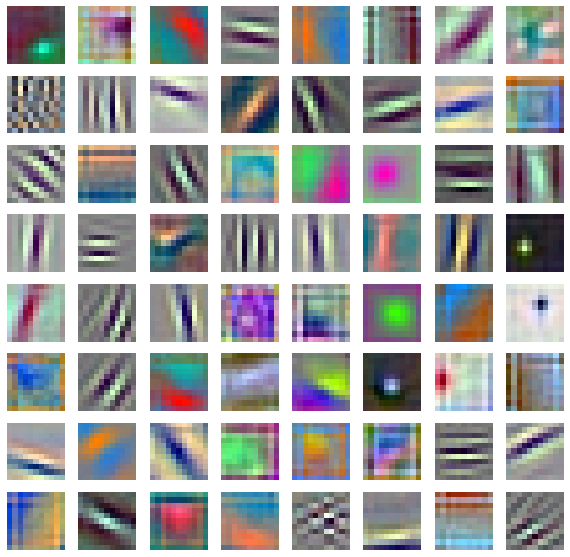

In [62]:

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i in range(64):
    axes[i // 8][i % 8].imshow(filters_[i], cmap='gray')
    axes[i // 8][i % 8].axis('off')